# Configuracion

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from quant_utils import FinancialStats, PortfolioOptimizer, QuantPlotter, Inviu


mi_broker = Inviu(con_asesor=True, considerar_iva=True) 

# Configuración de estilo
sns.set_theme(style="darkgrid")

# Extraccion de datos

In [36]:
# 1. Descargamos los datos desde la API pública
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]
print("Descargando precios de cierre ajustados...")
df_precios = yf.download(tickers, start="2024-01-01", end="2025-12-31",auto_adjust=False)["Adj Close"]

# 2. Dividimos temporalmente el dataset (Fiel al workflow profesional)
precios_2024 = df_precios.loc["2024-01-01":"2024-12-31"] # Entrenamiento (In-Sample)
precios_2025 = df_precios.loc["2025-01-01":"2025-12-31"] # Validación (Out-of-Sample)

print(f"Dataset cargado. Días de Bolsa en 2024: {len(precios_2024)} | En 2025: {len(precios_2025)}")

[*********************100%***********************]  6 of 6 completed

Descargando precios de cierre ajustados...
Dataset cargado. Días de Bolsa en 2024: 252 | En 2025: 249


# Fase de optimizacion 


=== ESTRATEGIA FIJADA (PESOS MÁXIMO SHARPE 2024) ===
 - AAPL: 40.48%
 - MSFT: 0.00%
 - GOOGL: 4.48%
 - AMZN: 22.38%
 - NVDA: 0.00%
 - META: 32.65%


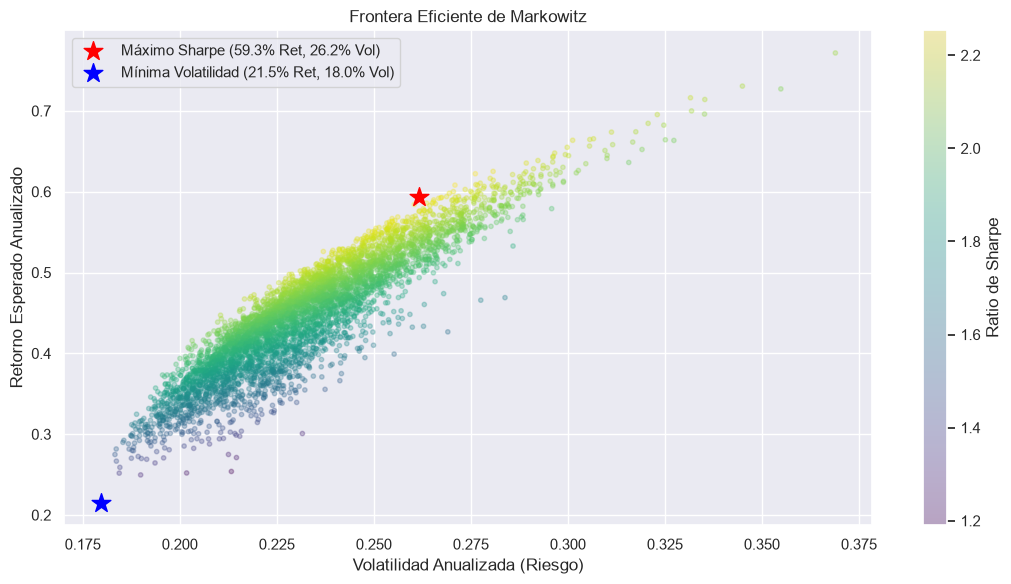

In [37]:
# 1. Transformamos los precios de 2024 en retornos logarítmicos usando tu módulo stats
retornos_2024 = FinancialStats.calcular_retornos_log(precios_2024)

# 2. Corremos el optimizador de SciPy que programaste en tu módulo optimization
pesos_optimos_2024 = PortfolioOptimizer.max_sharpe(retornos_2024)

print("\n=== ESTRATEGIA FIJADA (PESOS MÁXIMO SHARPE 2024) ===")
for t, w in zip(tickers, pesos_optimos_2024):
    print(f" - {t}: {w*100:.2f}%")

# Visualizamos la frontera eficiente real del 2024 con tu graficador
QuantPlotter.graficar_frontera_eficiente(retornos_2024)

# Backtesting de la estrategia 

In [38]:
# 1. Calculamos los retornos diarios del 2025
retornos_2025 = FinancialStats.calcular_retornos_log(precios_2025)

# 2. Multiplicación matricial para proyectar los retornos diarios de cada estrategia
retornos_markowitz_diarios = np.dot(retornos_2025, pesos_optimos_2024)

pesos_equitativos = np.array([1/len(tickers)] * len(tickers))
retornos_equitativo_diarios = np.dot(retornos_2025, pesos_equitativos)

# 3. Reconstruimos la Curva de Equidad (Evolución de $1 dólar inicial)
# Pasamos de retornos logarítmicos acumulados (suma) a retornos brutos (exponencial)
curva_markowitz = np.exp(np.cumsum(retornos_markowitz_diarios))
curva_equitativa = np.exp(np.cumsum(retornos_equitativo_diarios))

# Armamos un DataFrame indexado con las fechas reales del 2025
df_backtest = pd.DataFrame({
    'Estrategia Markowitz': curva_markowitz,
    'Portafolio Equitativo (1/N)': curva_equitativa
}, index=retornos_2025.index)

# Resultados de Backtesting

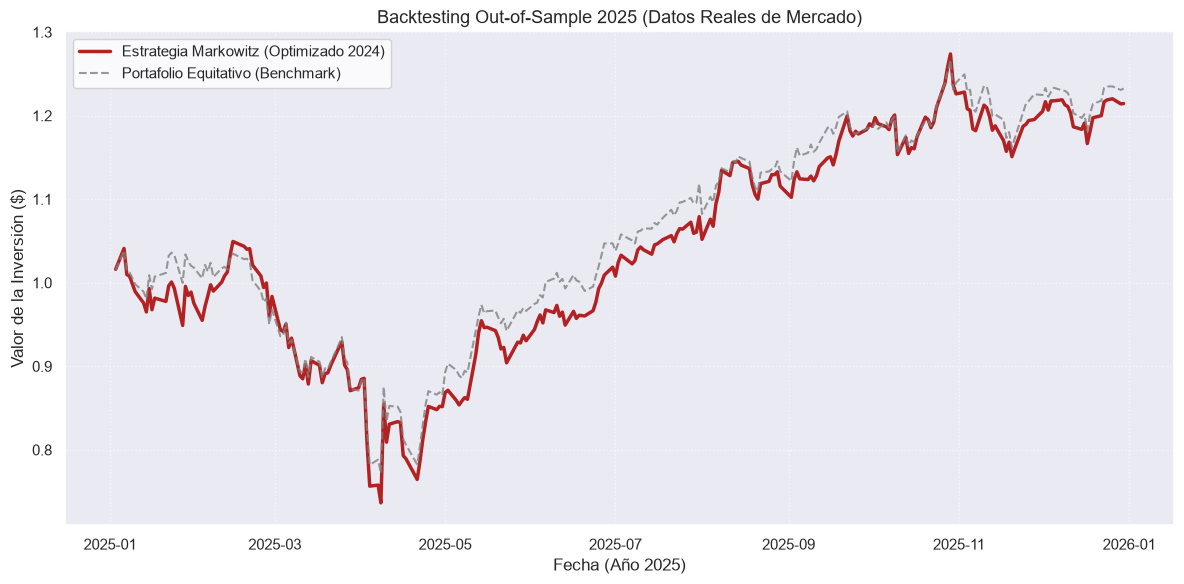

Rendimiento Final de tu Estrategia en 2025: 21.45%
Rendimiento Final del Portafolio Equitativo: 23.25%


In [39]:
plt.figure(figsize=(12, 6))
plt.plot(df_backtest['Estrategia Markowitz'], label='Estrategia Markowitz (Optimizado 2024)', color='firebrick', linewidth=2.5)
plt.plot(df_backtest['Portafolio Equitativo (1/N)'], label='Portafolio Equitativo (Benchmark)', color='gray', linestyle='--', alpha=0.8)

plt.title('Backtesting Out-of-Sample 2025 (Datos Reales de Mercado)', fontsize=13, fontweight='bold')
plt.xlabel('Fecha (Año 2025)')
plt.ylabel('Valor de la Inversión ($)')
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Métricas finales brutas
ganancia_markowitz = (df_backtest['Estrategia Markowitz'].iloc[-1] - 1) * 100
ganancia_equitativa = (df_backtest['Portafolio Equitativo (1/N)'].iloc[-1] - 1) * 100

print(f"Rendimiento Final de tu Estrategia en 2025: {ganancia_markowitz:.2f}%")
print(f"Rendimiento Final del Portafolio Equitativo: {ganancia_equitativa:.2f}%")

# Rebalanceo de Portafolios:

En lugar de optimizar una sola vez y cruzar los dedos todo el año, la lógica del rebalanceo dinámico funciona como un bucle temporal:

1. Empezamos en enero de 2025. Miramos los últimos 12 meses (todo 2024) y calculamos los pesos.
2. Dejamos correr el portafolio durante un mes.
3. Al finalizar el mes (febrero de 2025), "miramos hacia atrás" nuevamente, tomamos los últimos 12 meses actualizados, recalculamos los pesos óptimos y modificamos nuestra cartera.
4. Repetimos esto mes a mes.

In [40]:

meses_2025 = df_precios.loc["2025-01-01":"2025-12-31"].index.to_period('M').unique()

valores_portafolio_diarios = []
fechas_totales = []
capital_actual = 1.0  
pesos_actuales = np.array([0.0] * len(tickers))

for mes in meses_2025:
    # 1. Ventana móvil de entrenamiento
    fecha_fin_train = pd.Period(mes - 1, freq='M').to_timestamp(how='E')
    fecha_inicio_train = fecha_fin_train - pd.Timedelta(days=365)
    precios_train = df_precios.loc[fecha_inicio_train:fecha_fin_train]
    retornos_train = FinancialStats.calcular_retornos_log(precios_train)
    
    try:
        nuevos_pesos = PortfolioOptimizer.max_sharpe(retornos_train)
    except Exception:
        nuevos_pesos = pesos_actuales if np.sum(pesos_actuales) > 0 else np.array([1/len(tickers)]*len(tickers))
    
    # 2. Aplicar comisiones de Inviu sobre el cambio de cartera
    cambio_de_pesos = np.abs(nuevos_pesos - pesos_actuales)
    total_capital_operado = capital_actual * np.sum(cambio_de_pesos)
    costo_rebalanceo = mi_broker.calcular_costo_transaccion(total_capital_operado)
    
    capital_actual -= costo_rebalanceo
    pesos_actuales = nuevos_pesos 
    
    # 3. Correr el mes día por día
    fecha_inicio_mes = mes.to_timestamp(how='S')
    fecha_fin_mes = mes.to_timestamp(how='E')
    precios_mes = df_precios.loc[fecha_inicio_mes:fecha_fin_mes]
    
    if len(precios_mes) <= 1:
        continue
        
    retornos_mes = FinancialStats.calcular_retornos_log(precios_mes)
    retornos_portafolio_mes = np.dot(retornos_mes, pesos_actuales)
    
    # Clave: simular la evolución diaria e ir guardando cada cierre
    for ret_diario in retornos_portafolio_mes:
        capital_actual *= np.exp(ret_diario)
        valores_portafolio_diarios.append(capital_actual)
        
    # Guardamos TODOS los días del mes para el eje X
    fechas_totales.extend(retornos_mes.index)

# Guardamos la serie limpia libre de duplicados
serie_dinamica = pd.Series(valores_portafolio_diarios, index=fechas_totales)

df_backtest = df_backtest[~df_backtest.index.duplicated(keep='first')]
df_backtest['Estrategia Dinámica (Inviu)'] = serie_dinamica.groupby(serie_dinamica.index).first()
df_backtest['Estrategia Dinámica (Inviu)'] = df_backtest['Estrategia Dinámica (Inviu)'].ffill()

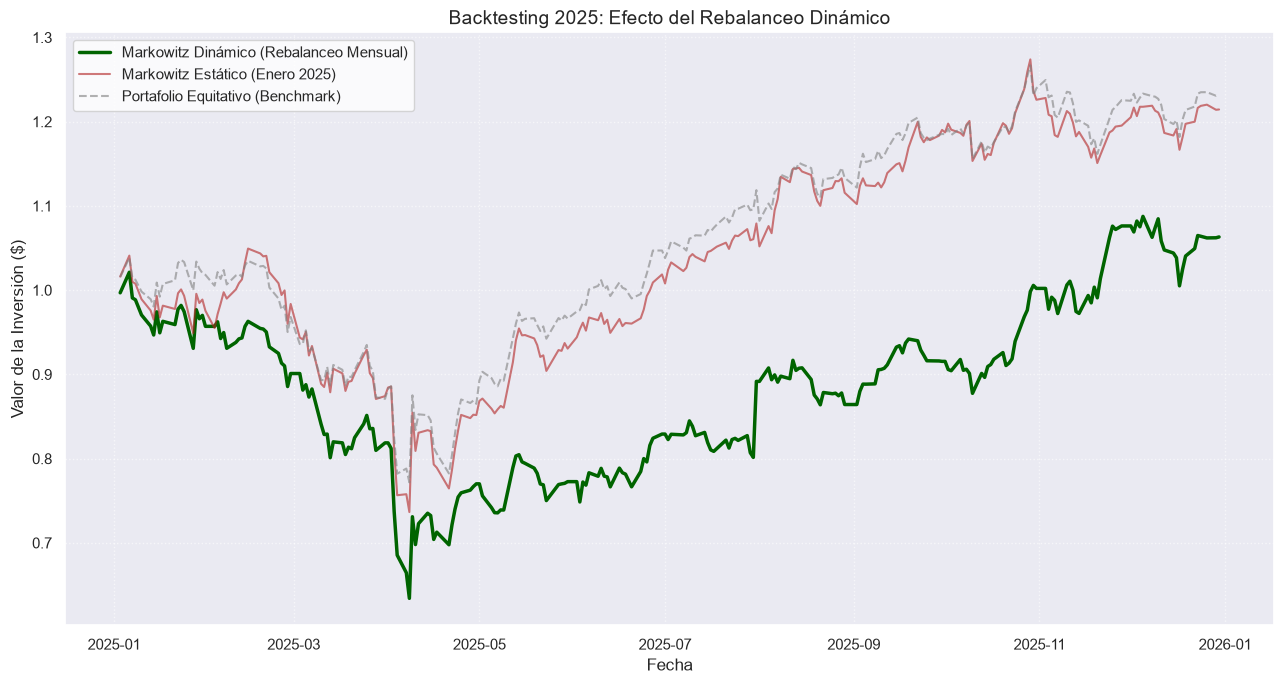

Rendimiento Final Markowitz Dinámico: 6.31%
Rendimiento Final Markowitz Estático: 21.45%
Rendimiento Final Portafolio Equitativo: 23.25%


In [41]:
plt.figure(figsize=(13, 7))
plt.plot(df_backtest['Estrategia Dinámica (Inviu)'], label='Markowitz Dinámico (Rebalanceo Mensual)', color='darkgreen', linewidth=2.5)
plt.plot(df_backtest['Estrategia Markowitz'], label='Markowitz Estático (Enero 2025)', color='firebrick', alpha=0.6)
plt.plot(df_backtest['Portafolio Equitativo (1/N)'], label='Portafolio Equitativo (Benchmark)', color='gray', linestyle='--', alpha=0.6)

plt.title('Backtesting 2025: Efecto del Rebalanceo Dinámico', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Inversión ($)')
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Reporte final de rendimientos
rend_dinamico = (df_backtest['Estrategia Dinámica (Inviu)'].dropna().iloc[-1] - 1) * 100
rend_estatico = (df_backtest['Estrategia Markowitz'].dropna().iloc[-1] - 1) * 100
rend_equitativo = (df_backtest['Portafolio Equitativo (1/N)'].dropna().iloc[-1] - 1) * 100

print(f"Rendimiento Final Markowitz Dinámico: {rend_dinamico:.2f}%")
print(f"Rendimiento Final Markowitz Estático: {rend_estatico:.2f}%")
print(f"Rendimiento Final Portafolio Equitativo: {rend_equitativo:.2f}%")

# Conclusiones

Desde una perspectiva puramente matemática y estática para este año en particular, no, no valió la pena el esfuerzo computacional. Pero en el análisis cuantitativo profesional, la respuesta cambia drásticamente por tres razones de peso:

### 1. El alfa acumulado y el interés compuesto

Un ~1% de diferencia (lo que en finanzas llamamos 100 puntos básicos o basis points) parece un vuelto en una cuenta de $1.000 dólares. Pero escalemos esto a un fondo de inversión que maneja 100 millones de dólares: ese 1% extra son 1 millón de dólares más de ganancia pura en un año.

Si encima proyectás ese 1% de ventaja compuesto a lo largo de 10 o 15 años, la diferencia entre las dos curvas se vuelve un abismo geométrico. El software se paga solo con el volumen y el tiempo.

### 2. La trampa de mirar solo el final (El Riesgo Oculto)

Mirar solo el rendimiento final es como evaluar un auto de carreras solo por si llegó a la meta, sin mirar cuántas veces casi se pega contra el paredón.

Fijate en la gráfica lo que pasó entre mayo y septiembre de 2025:

- La línea verde estuvo muy por debajo de las otras dos durante meses. Tuvo un drawdown (caída desde el máximo) mucho más profundo y doloroso.

- Si vos fueras el gestor de un fondo real, durante esos 4 meses de malaria tus clientes te habrían prendido fuego el teléfono preguntándote por qué la estrategia ultra optimizada iba perdiendo por paliza contra el portafolio tonto.

Esto te demuestra que el Markowitz Dinámico logró más retorno final, pero a costa de hacerte sufrir mucho más estrés numérico. Financieramente, si calculamos el Ratio de Sharpe real de 2025, el portafolio equitativo probablemente gane en "calidad de vida" y consistencia riesgo-retorno.

### 3. Los costos ocultos del mundo real (Costos de Transacción)

Acá viene el baldazo de agua fría de la realidad del mercado: en tu simulación, el rebalanceo mensual es "gratis". En la bolsa real, cada vez que el bucle verde decide vender un pedazo de Apple para comprar Nvidia, el bróker te cobra una comisión por operación, y además el Estado te cobra impuestos por ganancias realizadas.

Si le restás esos costos de transacción a la línea verde por operar 12 veces al año en lugar de dejar el portafolio quieto, ese 1% de ventaja desaparece por completo y probablemente termine perdiendo contra el equitativo.

